# Project 4 - spatial Niches in mIF Data

#### Imports and data

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree

In [ ]:
DATA_DIR = "unzipped/tsv/cells_properties"

patient_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_with_celltype.tsv")))

print(f"Found {len(patient_files)} patient files:")
for f in patient_files:
    print(os.path.basename(f))

Found 15 patient files:
LUNG-NSCLC2-0558-FIXT-01-IF1-01_#_cells_properties_#_f9e776cbf3f124bd9a0d3af7ab4423ba_with_celltype.tsv
LUNG-NSCLC2-0565-FIXT-01-IF1-01_#_cells_properties_#_12cf4d92f8de6204055505affdf85e90_with_celltype.tsv
LUNG-NSCLC2-0587-FIXT-01-IF1-01_#_cells_properties_#_fb439474f2166fe87b6d3087643b2af3_with_celltype.tsv
LUNG-NSCLC2-0591-FIXT-01-IF1-01_#_cells_properties_#_b17f2afaad57821d4888ff6ba7f4b179_with_celltype.tsv
LUNG-NSCLC2-0593-FIXT-01-IF1-01_#_cells_properties_#_d070103e8b485c517639081c33e45ded_with_celltype.tsv
LUNG-NSCLC2-0612-FIXT-01-IF1-01_#_cells_properties_#_c948f5405a3f2243d3ef6d678823d805_with_celltype.tsv
LUNG-NSCLC2-0613-FIXT-01-IF1-01_#_cells_properties_#_53ec91fc9c63f3088eb688a53912ac53_with_celltype.tsv
LUNG-NSCLC2-0616-FIXT-01-IF1-01_#_cells_properties_#_99f9f40cba303b42b5a251859509f000_with_celltype.tsv
LUNG-NSCLC2-0657-FIXT-01-IF1-01_#_cells_properties_#_c1cca8eabb109ca29cb7c2a4530fd76e_with_celltype.tsv
LUNG-NSCLC2-0659-FIXT-01-IF1-01_#_cells_

In [ ]:
  #Extract short patient ID from the file name.
def get_patient_id_from_path(path):
    long_id = os.path.basename(path).replace("_with_celltype.tsv", "").split("_#_")[0]
    short_id = long_id.split("-")[2]
    return short_id

In [7]:
# Read all patients into one table.
dfs = []

for path in patient_files:
    tmp = pd.read_csv(path, sep="\t")
    tmp["patient"] = get_patient_id_from_path(path)
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print("Shape:", df.shape)
print("Number of patients:", df["patient"].nunique())
print("Patients:", sorted(df["patient"].unique()))

df.head()

Shape: (18968569, 26)
Number of patients: 15
Patients: ['0558', '0565', '0587', '0591', '0593', '0612', '0613', '0616', '0657', '0659', '0664', '0695', '0696', '0699', '0721']


,cell.ID,nucleus.x,nucleus.y,CD15.score,CK.score,CD3.score,CD11c.score,CD20.score,CD163.score,CD15.score.normalized,...,phenotype,in.ROI.next_to_tumor_tissue,in.ROI.tumor_tissue,cell.type,patient,in.ROI.necrosis,in.ROI.adipose_tissue,in.ROI.1,in.ROI.2,in.ROI.3
0,1,6441.5,37984.3,0.755990,0.557696,2.339746,0.258212,0.259974,1.439782,0.0391,...,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,other,0558,NaN,NaN,NaN,NaN,NaN
1,2,6269.3,37743.1,0.836617,0.557638,3.188341,0.390046,0.181936,61.754458,0.0432,...,CD15-CK-CD3-CD11c-CD20-CD163+,False,True,Macrophage,0558,NaN,NaN,NaN,NaN,NaN
2,3,6454.4,37814.1,0.589492,0.557628,15.492811,0.320116,0.171355,2.378751,0.0305,...,CD15-CK-CD3+CD11c-CD20-CD163-,False,True,Tcell,0558,NaN,NaN,NaN,NaN,NaN
3,4,6677.6,37760.0,41.572382,0.555882,2.700532,1.368053,0.172937,2.184452,2.1484,...,CD15+CK-CD3-CD11c-CD20-CD163-,False,True,Neutrophil,0558,NaN,NaN,NaN,NaN,NaN
4,5,6853.3,37688.5,1.739946,2.323499,3.762925,1.219106,0.473835,18.794610,0.0899,...,CD15-CK-CD3-CD11c-CD20-CD163-,False,True,other,0558,NaN,NaN,NaN,NaN,NaN


In [8]:
# Input data inspection.

print("Columns:")
print(df.columns.tolist())

print("\nCell type counts:")
print(df["cell.type"].value_counts())

print("\nTissue type counts:")
print(df["tissue.type"].value_counts())

print("\nTumour ROI annotation:")
print(df["in.ROI.tumor_tissue"].value_counts(dropna=False))

print("\nNext-to-tumour ROI annotation:")
print(df["in.ROI.next_to_tumor_tissue"].value_counts(dropna=False))

Columns:
['cell.ID', 'nucleus.x', 'nucleus.y', 'CD15.score', 'CK.score', 'CD3.score', 'CD11c.score', 'CD20.score', 'CD163.score', 'CD15.score.normalized', 'CK.score.normalized', 'CD3.score.normalized', 'CD11c.score.normalized', 'CD20.score.normalized', 'CD163.score.normalized', 'tissue.type', 'phenotype', 'in.ROI.next_to_tumor_tissue', 'in.ROI.tumor_tissue', 'cell.type', 'patient', 'in.ROI.necrosis', 'in.ROI.adipose_tissue', 'in.ROI.1', 'in.ROI.2', 'in.ROI.3']

Cell type counts:
cell.type
CD15-Tumor    7270562
other         5742965
Tcell         2581921
Macrophage    1547072
CD15+Tumor     575279
Neutrophil     572029
Bcell          381942
BnTcell        256627
DC              40172
Name: count, dtype: int64

Tissue type counts:
tissue.type
stroma    9988751
tumor     8979818
Name: count, dtype: int64

Tumour ROI annotation:
in.ROI.tumor_tissue
True     9979906
False    5256805
NaN      3731858
Name: count, dtype: int64

Next-to-tumour ROI annotation:
in.ROI.next_to_tumor_tissue
False 

## D1: Immune-Cell Infiltration Profiles

In [ ]:
# Check tumour ROI annotation per patient.
roi_check = (
    df.groupby("patient")
    .agg(
        n_cells=("cell.ID", "count"),
        n_tissue_tumor=("tissue.type", lambda x: (x == "tumor").sum()),
        n_tissue_stroma=("tissue.type", lambda x: (x == "stroma").sum()),
        n_tumour_roi=(ROI_COL, lambda x: (x == True).sum()),
        n_next_to_tumour_roi=("in.ROI.next_to_tumor_tissue", lambda x: (x == True).sum())
    )
    .reset_index()
)

roi_check["has_tumour_roi"] = roi_check["n_tumour_roi"] > 0

roi_check

,patient,n_cells,n_tissue_tumor,n_tissue_stroma,n_tumour_roi,n_next_to_tumour_roi,has_tumour_roi
0,0558,1291514,248932,1042582,1015934,254522,True
1,0565,1237771,618597,619174,725269,479825,True
2,0587,1233608,471996,761612,991195,198497,True
3,0591,1221562,623454,598108,1019643,192849,True
4,0593,1276128,491599,784529,807049,457872,True
5,0612,1258052,928972,329080,960385,124850,True
6,0613,1202428,501394,701034,1077971,110420,True
7,0616,1313146,691684,621462,1048737,227936,True
8,0657,1307594,562347,745247,277498,1025101,True
9,0659,1268844,686119,582725,533668,647874,True


In [ ]:
ROI_COL = "in.ROI.tumor_tissue"

def compute_border_distance_for_patient(patient_df):
    """
    Compute border distance for one patient.

    Some patients have no positive tumour ROI annotation,
    for them we use all cells annotated as tissue.type == 'tumor'
    to keep all 15 patients in the analysis.
    """

    patient_df = patient_df.copy()

    coords = patient_df[["nucleus.x", "nucleus.y"]].to_numpy()

    is_tumor = patient_df["tissue.type"].to_numpy() == "tumor"
    is_stroma = patient_df["tissue.type"].to_numpy() == "stroma"

    patient_df["border_distance"] = np.nan

    if not is_tumor.any() or not is_stroma.any():
        return patient_df.iloc[0:0].copy()

    # Build a KD-tree on stromal cells.
    # This lets us efficiently find the nearest stromal cell for each tumour cell.
    stroma_tree = cKDTree(coords[is_stroma])
    distances, _ = stroma_tree.query(coords[is_tumor], k=1)

    patient_df.loc[is_tumor, "border_distance"] = distances

    # Prefer tumour ROI if available.
    if ROI_COL in patient_df.columns and patient_df[ROI_COL].sum() > 0:
        tumour_focus = (patient_df[ROI_COL] == True) & (patient_df["tissue.type"] == "tumor")
        roi_definition = "tumour ROI"
    else:
        tumour_focus = patient_df["tissue.type"] == "tumor"
        roi_definition = "tissue.type == tumor fallback"

    tumour_cells = patient_df[tumour_focus].copy()
    tumour_cells["roi_definition"] = roi_definition

    return tumour_cells

In [13]:
# Compute border distances for all patients.

d1_tables = []

for patient in sorted(df["patient"].unique()):
    patient_df = df[df["patient"] == patient].copy()
    result = compute_border_distance_for_patient(patient_df)
    d1_tables.append(result)

d1_df = pd.concat(d1_tables, ignore_index=True)

print("Patients in D1:", d1_df["patient"].nunique())
print("Shape:", d1_df.shape)

d1_df[["patient", "cell.ID", "cell.type", "tissue.type", "border_distance", "roi_definition"]].head()

Patients in D1: 15
Shape: (6506400, 28)


,patient,cell.ID,cell.type,tissue.type,border_distance,roi_definition
0,0558,38,CD15-Tumor,tumor,11.574109,tumour ROI
1,0558,46,CD15-Tumor,tumor,11.448144,tumour ROI
2,0558,47,CD15-Tumor,tumor,16.095341,tumour ROI
3,0558,66,CD15-Tumor,tumor,20.089052,tumour ROI
4,0558,71,CD15-Tumor,tumor,8.062258,tumour ROI


#### Border-distance distributions 

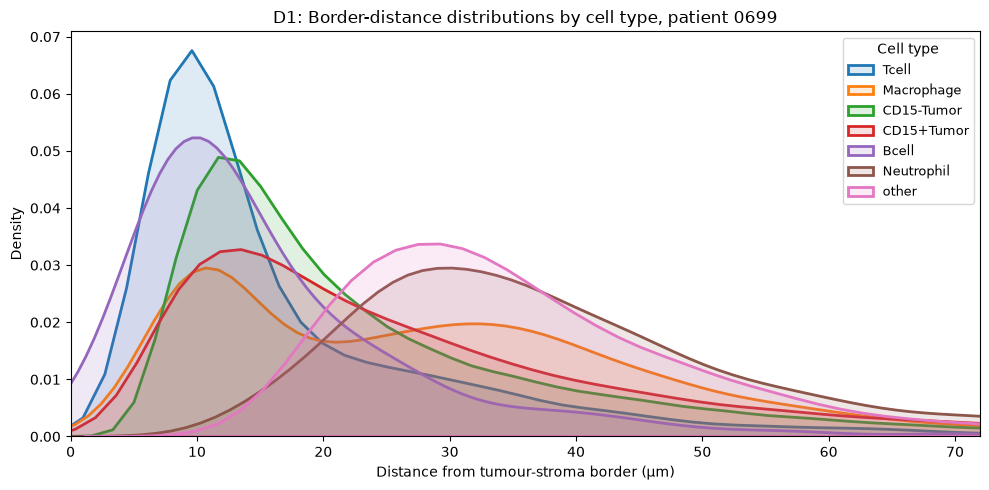

In [40]:
# Example patient used for detailed visualisation.

example_patient = "0699"

cell_types_to_plot = [
    "Tcell",
    "Macrophage",
    "CD15-Tumor",
    "CD15+Tumor",
    "Bcell",
    "Neutrophil",
    "other"
]

example_df = d1_df[
    (d1_df["patient"] == example_patient) &
    (d1_df["cell.type"].isin(cell_types_to_plot))
].copy()

plt.figure(figsize=(10, 5))

for ct in cell_types_to_plot:
    sub = example_df[example_df["cell.type"] == ct]

    # KDE needs enough values and non-constant distances.
    if len(sub) > 50 and sub["border_distance"].nunique() > 1:
        sns.kdeplot(
            data=sub,
            x="border_distance",
            label=ct,
            fill=True,
            alpha=0.14,
            linewidth=2,
            common_norm=False
        )

# Use 97th percentile to avoid a long sparse tail making the plot unreadable.
xlim = example_df["border_distance"].quantile(0.97)
plt.xlim(0, xlim)

plt.xlabel("Distance from tumour-stroma border (µm)")
plt.ylabel("Density")
plt.title(f"D1: Border-distance distributions by cell type, patient {example_patient}")
plt.legend(title="Cell type", fontsize=9)
plt.tight_layout()
plt.show()

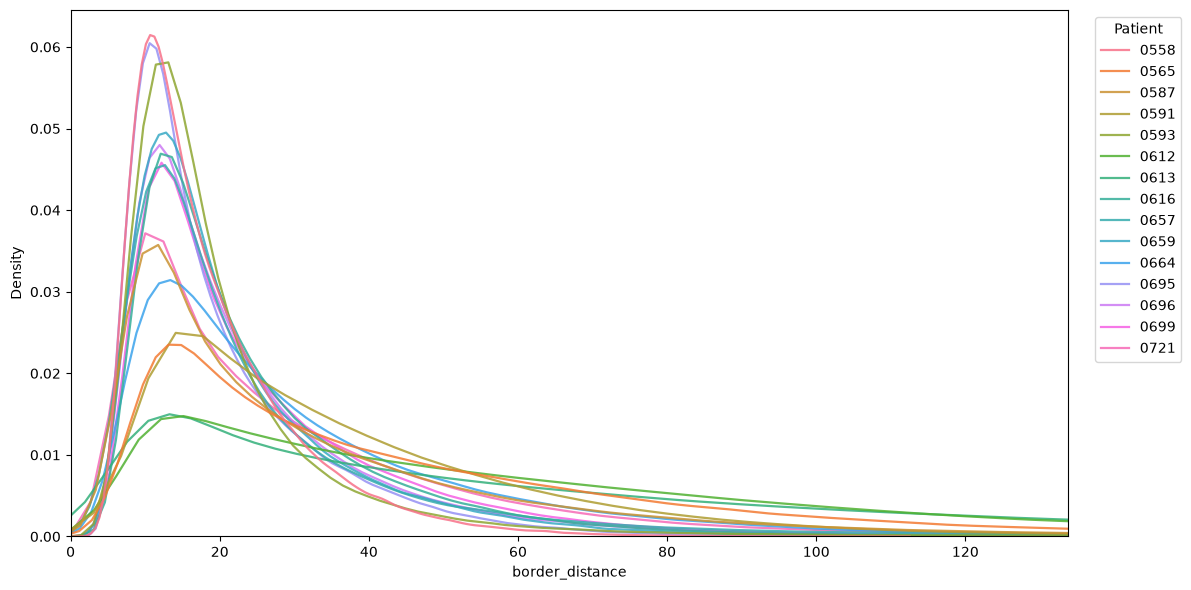

In [30]:
# Border-distance distributions for all patients on one plot.

plt.figure(figsize=(12, 6))
g = sns.kdeplot(
    data=d1_df,
    x="border_distance",
    hue="patient",
    common_norm=False,
    fill=False,
    linewidth=1.6,
    alpha=0.85
)

plt.xlim(0, d1_df["border_distance"].quantile(0.97))
sns.move_legend(g, "upper left", bbox_to_anchor=(1.02, 1), title="Patient")
plt.tight_layout()
plt.show()

#### T-cell infiltration profiles 

In [ ]:
D1_BINS = [0, 10, 20, 40, 80, 120, 200, np.inf]
D1_LABELS = ["0-10", "10-20", "20-40", "40-80", "80-120", "120-200", "200+"]

d1_df["distance_bin"] = pd.cut(
    d1_df["border_distance"],
    bins=D1_BINS,
    labels=D1_LABELS,
    include_lowest=True
)

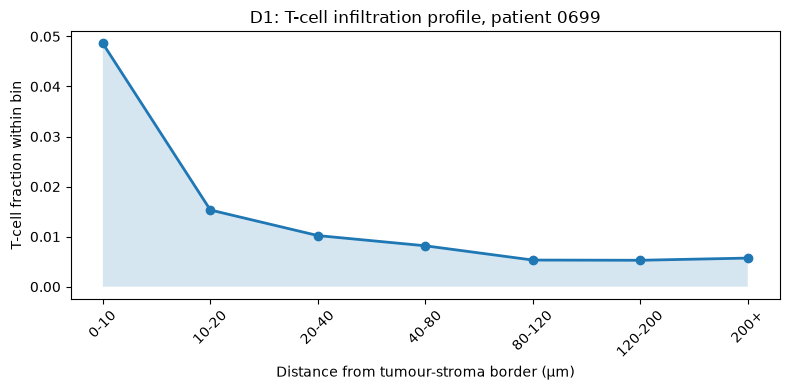

,distance_bin,n_cells,n_tcells,tcell_density
0,0-10,50073,2433,0.048589
1,10-20,161582,2476,0.015323
2,20-40,128576,1313,0.010212
3,40-80,59965,490,0.008171
4,80-120,6578,35,0.005321
5,120-200,1326,7,0.005279
6,200+,175,1,0.005714


In [46]:

one_patient_profile = (
    d1_df[d1_df["patient"] == example_patient]
    .groupby("distance_bin", observed=False)
    .apply(lambda x: pd.Series({
        "n_cells": len(x),
        "n_tcells": (x["cell.type"] == "Tcell").sum()
    }))
    .reset_index()
)

one_patient_profile["tcell_density"] = (
    one_patient_profile["n_tcells"] / one_patient_profile["n_cells"]
)

plt.figure(figsize=(8, 4))

plt.plot(
    one_patient_profile["distance_bin"].astype(str),
    one_patient_profile["tcell_density"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    one_patient_profile["distance_bin"].astype(str),
    one_patient_profile["tcell_density"],
    alpha=0.18
)

plt.xlabel("Distance from tumour-stroma border (µm)")
plt.ylabel("T-cell fraction within bin")
plt.title(f"D1: T-cell infiltration profile, patient {example_patient}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

one_patient_profile

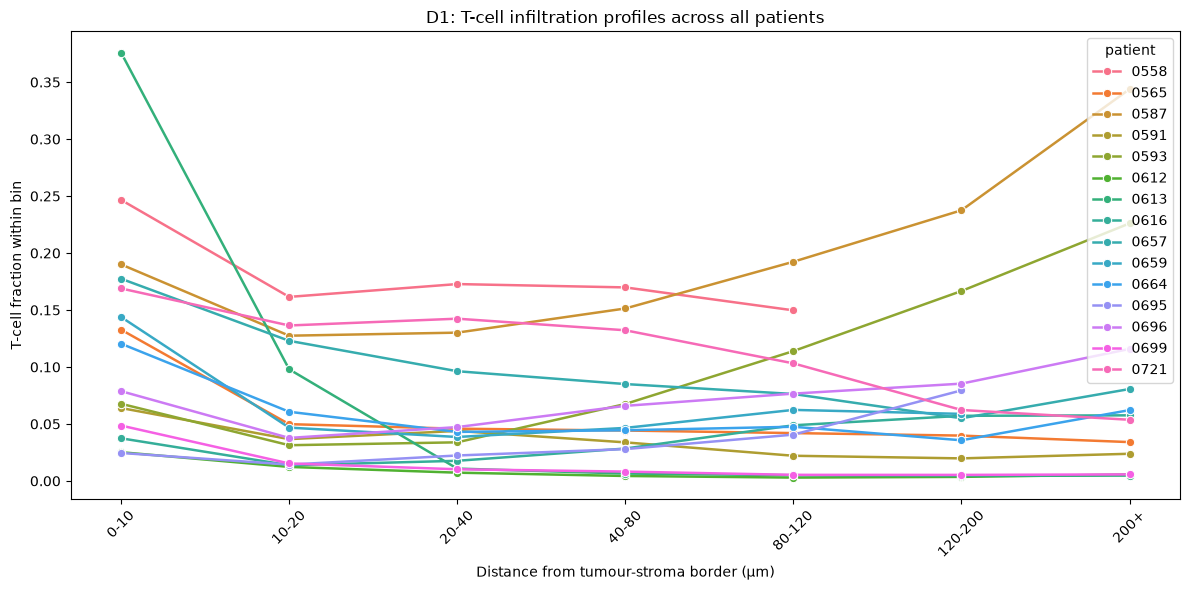

In [38]:
all_tcell_profiles = (
    d1_df
    .groupby(["patient", "distance_bin"], observed=False)
    .apply(lambda x: pd.Series({
        "n_cells": len(x),
        "n_tcells": (x["cell.type"] == "Tcell").sum()
    }))
    .reset_index()
)

all_tcell_profiles["tcell_density"] = (
    all_tcell_profiles["n_tcells"] / all_tcell_profiles["n_cells"]
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=all_tcell_profiles,
    x="distance_bin",
    y="tcell_density",
    hue="patient",
    marker="o",
    linewidth=1.8
)

plt.xlabel("Distance from tumour-stroma border (µm)")
plt.ylabel("T-cell fraction within bin")
plt.title("D1: T-cell infiltration profiles across all patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Patient-level T-cell infiltration score.
# Score = median border distance of T cells.

scores = []

for patient in sorted(d1_df["patient"].unique()):

    tmp = d1_df[
        (d1_df["patient"] == patient) &
        (d1_df["cell.type"] == "Tcell")
    ].copy()

    score = tmp["border_distance"].median()

    scores.append({
        "patient": patient,
        "tcell_infiltration_score": score,
        "n_tcells": len(tmp)
    })

scores_df = pd.DataFrame(scores)

scores_df = scores_df.sort_values(
    "tcell_infiltration_score",
    ascending=False
)

scores_df

,patient,tcell_infiltration_score,n_tcells
1,0565,27.511816,21008
3,0591,27.089666,23156
2,0587,23.298712,57688
5,0612,22.370740,5363
7,0616,20.618923,11477
14,0721,20.188363,92884
12,0696,18.752333,28757
10,0664,17.740631,7706
11,0695,17.548219,15124
8,0657,15.033629,8055


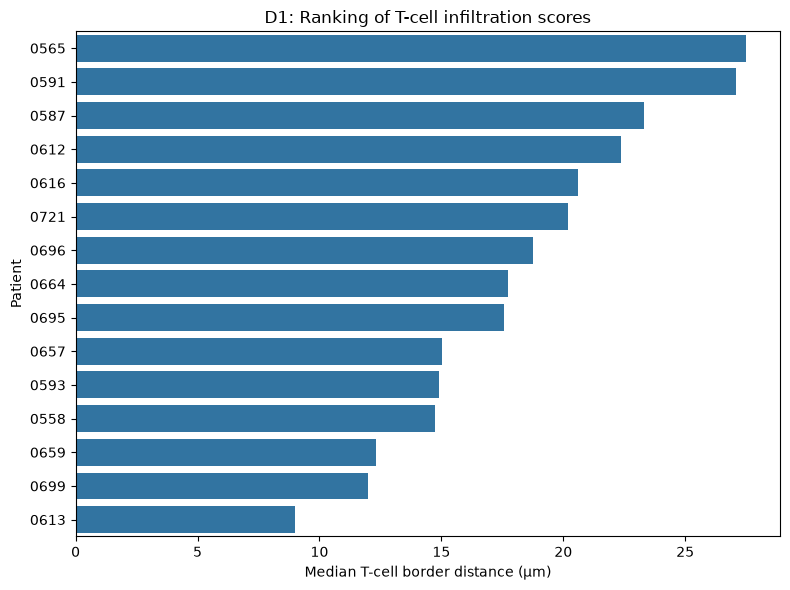

In [42]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=scores_df,
    x="tcell_infiltration_score",
    y="patient"
)

plt.xlabel("Median T-cell border distance (µm)")
plt.ylabel("Patient")
plt.title("D1: Ranking of T-cell infiltration scores")

plt.tight_layout()
plt.show()

In [43]:
scores_df["tcell_infiltration_score"].describe()

count    15.000000
mean     18.207918
std       5.413581
min       9.013878
25%      14.823386
50%      17.740631
75%      21.494832
max      27.511816
Name: tcell_infiltration_score, dtype: float64

In [44]:
q33 = scores_df["tcell_infiltration_score"].quantile(0.33)
q66 = scores_df["tcell_infiltration_score"].quantile(0.66)

q33, q66

(np.float64(14.986036983752864), np.float64(20.29169747167535))

In [45]:
def classify_patient(score):

    if score >= q66:
        return "infiltrated"

    elif score <= q33:
        return "excluded"

    else:
        return "mixed"

scores_df["pattern"] = scores_df[
    "tcell_infiltration_score"
].apply(classify_patient)

scores_df

,patient,tcell_infiltration_score,n_tcells,pattern
1,0565,27.511816,21008,infiltrated
3,0591,27.089666,23156,infiltrated
2,0587,23.298712,57688,infiltrated
5,0612,22.370740,5363,infiltrated
7,0616,20.618923,11477,infiltrated
14,0721,20.188363,92884,mixed
12,0696,18.752333,28757,mixed
10,0664,17.740631,7706,mixed
11,0695,17.548219,15124,mixed
8,0657,15.033629,8055,mixed


Patients with high T-cell infiltration scores had the largest median border distances of T cells. This indicates that a substantial fraction of T cells is located deeper inside tumour tissue rather than remaining near the tumour–stroma interface. These tumours therefore exhibit an infiltrated (inflamed) phenotype, suggesting more effective immune-cell penetration into the tumour microenvironment.


Patients with intermediate scores displayed neither strong exclusion nor strong infiltration. T cells were distributed across both border and deeper tumour regions, resulting in a mixed/intermediate phenotype. These tumours likely represent transitional states between fully infiltrated and strongly excluded immune microenvironments.


Patients with low infiltration scores had T cells located much closer to the tumour border. This pattern is consistent with an immune-excluded phenotype, where immune cells accumulate near the tumour–stroma interface but do not efficiently penetrate deeper tumour regions. Patient 0613 showed the strongest exclusion pattern, having the lowest infiltration score in the cohort.



### Biological comparison

Based on the T-cell infiltration score, patients were classified as infiltrated, mixed or immune-excluded. Patients 0565, 0591, 0587, 0612 and 0616 showed the highest infiltration scores and were therefore classified as infiltrated tumours. These patients tended to exhibit larger fractions of the immune-infiltrated tumour niche (Niche 2), indicating that T cells were able to penetrate deeper into tumour tissue rather than remaining confined to the tumour border.

Patients 0593, 0558, 0659, 0699 and 0613 showed the lowest infiltration scores and were classified as immune-excluded tumours. In these cases, T cells were concentrated close to the tumour–stroma interface and showed limited penetration into deeper tumour regions. These patients were generally characterised by larger fractions of tumour-dominated niches and lower representation of the immune-infiltrated niche.

Patients 0721, 0696, 0664, 0695 and 0657 displayed intermediate infiltration scores and were classified as mixed tumours. Their T-cell distributions were neither strongly infiltrated nor strongly excluded, suggesting a transitional spatial organisation. These patients typically showed a more balanced mixture of tumour-rich, stromal and immune-containing niches.

Overall, the infiltration score successfully separated patients into biologically distinct groups ranging from immune-excluded tumours with limited T-cell penetration to inflamed tumours with deeper immune infiltration. The niche analysis further supported this interpretation by showing that highly infiltrated tumours tended to contain larger fractions of immune-associated niches, whereas excluded tumours were dominated by tumour-centred spatial niches.

## D2:  Moran’s I Spatial Clustering

#### Implementation

In [47]:
from sklearn.neighbors import NearestNeighbors

K_NN = 10
N_PERM = 500
RANDOM_STATE = 42

In [ ]:
def build_knn_graph(coords, k=10):
    """
    Build a k-nearest-neighbour graph from spatial coordinates.
    """
    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(coords)
    knn_idx = nn.kneighbors(coords, return_distance=False)[:, 1:]
    return knn_idx

In [52]:
def morans_i(values, knn_idx):
    """
    Compute Moran's I on a k-NN graph.
    """
    values = np.asarray(values, dtype=float)

    n = len(values)
    k = knn_idx.shape[1]
    W = n * k

    z = values - values.mean()
    denominator = np.sum(z ** 2)

    if denominator == 0:
        return np.nan

    numerator = np.sum(z * z[knn_idx].sum(axis=1))

    return (n / W) * (numerator / denominator)

In [ ]:
# Sanity check on synthetic data.
# Create 3 patterns:
# clustered - same labels grouped together
# random - labels randomly shuffled
# dispersed - checkerboard-like alternating labels

grid_size = 50
x, y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))
coords_grid = np.column_stack([x.ravel(), y.ravel()])

knn_grid = build_knn_graph(coords_grid, k=4)

rows = coords_grid[:, 1]
cols = coords_grid[:, 0]

clustered = (rows > grid_size / 2).astype(float)
random_labels = np.random.default_rng(42).permutation(clustered)
dispersed = ((rows + cols) % 2).astype(float)

sanity_results = pd.DataFrame({
    "pattern": ["clustered", "random", "dispersed"],
    "Moran_I": [
        morans_i(clustered, knn_grid),
        morans_i(random_labels, knn_grid),
        morans_i(dispersed, knn_grid)
    ]
})

sanity_results

,pattern,Moran_I
0,clustered,0.979375
1,random,0.001587
2,dispersed,-0.960000


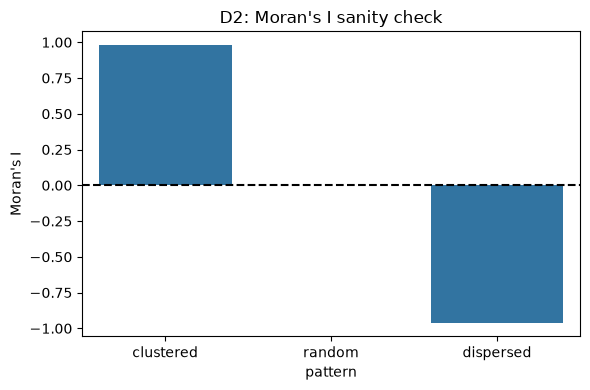

In [54]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=sanity_results,
    x="pattern",
    y="Moran_I"
)

plt.axhline(0, color="black", linestyle="--")
plt.ylabel("Moran's I")
plt.title("D2: Moran's I sanity check")
plt.tight_layout()
plt.show()

In [56]:
# Permutation null
def morans_i_permutation_test(values, knn_idx, n_perm=500, seed=42):
    """
    Permutation test for Moran's I.
    """
    rng = np.random.default_rng(seed)

    observed = morans_i(values, knn_idx)

    null_values = []

    for _ in range(n_perm):
        shuffled = rng.permutation(values)
        null_values.append(morans_i(shuffled, knn_idx))

    null_values = np.array(null_values)

    p_value = (np.sum(null_values >= observed) + 1) / (n_perm + 1)

    return {
        "observed_I": observed,
        "null_mean": null_values.mean(),
        "null_low": np.quantile(null_values, 0.025),
        "null_high": np.quantile(null_values, 0.975),
        "p_value": p_value
    }

### Cell-type results

In [57]:
#Moran’s I for 9 cell types, one patient

patient_df = df[df["patient"] == example_patient].copy()

# Subsample for speed and memory. This keeps the analysis reproducible.
N_SUB = 80000

if len(patient_df) > N_SUB:
    patient_df = patient_df.sample(N_SUB, random_state=42).copy()

patient_df = patient_df.reset_index(drop=True)

coords = patient_df[["nucleus.x", "nucleus.y"]].to_numpy()
knn_idx = build_knn_graph(coords, k=K_NN)

cell_types = sorted(patient_df["cell.type"].unique())

print(cell_types)
print("Number of cell types:", len(cell_types))

['Bcell', 'BnTcell', 'CD15+Tumor', 'CD15-Tumor', 'DC', 'Macrophage', 'Neutrophil', 'Tcell', 'other']
Number of cell types: 9


In [58]:
moran_results = []

for cell_type in cell_types:
    values = (patient_df["cell.type"] == cell_type).astype(float).to_numpy()

    if values.sum() < 10:
        continue

    result = morans_i_permutation_test(
        values,
        knn_idx,
        n_perm=N_PERM,
        seed=42
    )

    moran_results.append({
        "cell_type": cell_type,
        "Moran_I": result["observed_I"],
        "null_mean": result["null_mean"],
        "null_low": result["null_low"],
        "null_high": result["null_high"],
        "p_value": result["p_value"],
        "n_cells": int(values.sum())
    })

moran_df = pd.DataFrame(moran_results)
moran_df = moran_df.sort_values("Moran_I", ascending=False)

moran_df

,cell_type,Moran_I,null_mean,null_low,null_high,p_value,n_cells
3,CD15-Tumor,0.313716,-0.000138,-0.003055,0.002876,0.001996,21611
0,Bcell,0.311356,0.000044,-0.002790,0.003424,0.001996,1109
2,CD15+Tumor,0.256050,-0.000136,-0.003086,0.003104,0.001996,3174
6,Neutrophil,0.206963,-0.000059,-0.003149,0.002827,0.001996,2444
1,BnTcell,0.191997,-0.000091,-0.002914,0.002943,0.001996,722
8,other,0.183483,-0.000004,-0.002811,0.003161,0.001996,33273
7,Tcell,0.125001,-0.000057,-0.002977,0.002726,0.001996,10898
4,DC,0.068335,-0.000011,-0.002754,0.002999,0.001996,702
5,Macrophage,0.067294,0.000004,-0.002618,0.002635,0.001996,6067


#### Clear figure

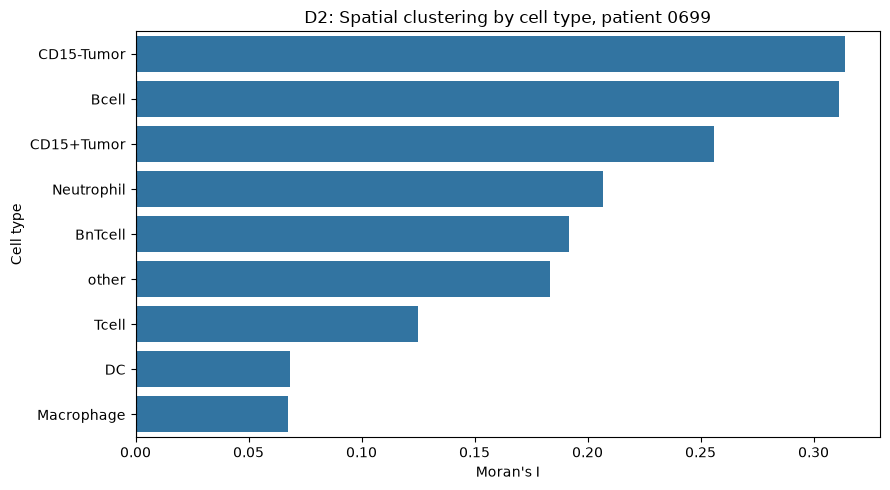

In [59]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=moran_df,
    x="Moran_I",
    y="cell_type"
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Moran's I")
plt.ylabel("Cell type")
plt.title(f"D2: Spatial clustering by cell type, patient {example_patient}")
plt.tight_layout()
plt.show()

INTERPRETATION: In patient 0699, all cell types showed positive Moran's I values, indicating spatial clustering. The strongest clustering was observed for CD15-Tumor, Bcell and CD15+Tumor cells, suggesting the presence of compact tumour and immune-cell regions. T cells showed intermediate clustering (Moran's I ≈ 0.12), indicating that they form local aggregates but are more spatially dispersed than tumour cells or B cells. Macrophages and dendritic cells exhibited the weakest clustering, suggesting a more diffuse distribution throughout the tissue.


#### Figure with permutation null intervals

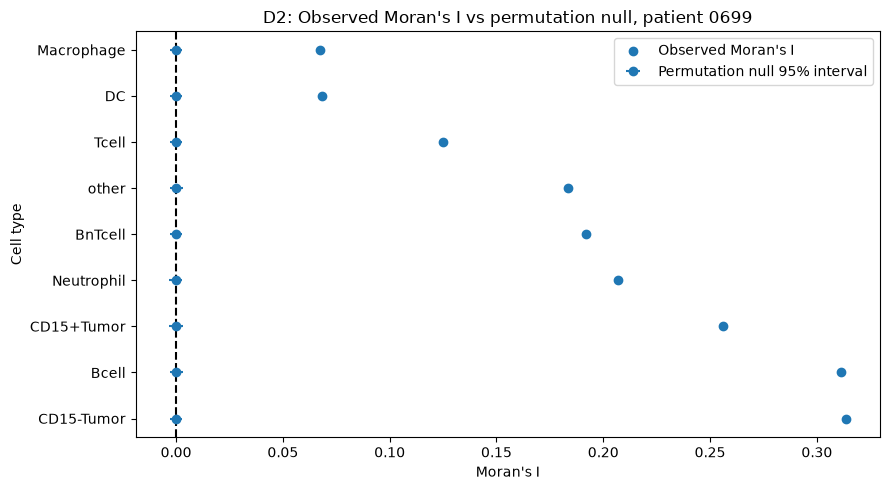

In [60]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    x=moran_df["null_mean"],
    y=moran_df["cell_type"],
    xerr=[
        moran_df["null_mean"] - moran_df["null_low"],
        moran_df["null_high"] - moran_df["null_mean"]
    ],
    fmt="o",
    label="Permutation null 95% interval"
)

plt.scatter(
    moran_df["Moran_I"],
    moran_df["cell_type"],
    label="Observed Moran's I"
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Moran's I")
plt.ylabel("Cell type")
plt.title(f"D2: Observed Moran's I vs permutation null, patient {example_patient}")
plt.legend()
plt.tight_layout()
plt.show()

INTERPRETATION: For all analysed cell types, the observed Moran's I values were substantially higher than the permutation-based null expectation, which were zero. This demonstrates that the detected clustering cannot be explained solely by cell-type abundance and reflects genuine spatial organisation. The strongest clustering was observed for CD15-Tumor and Bcell populations, whereas macrophages and dendritic cells showed the weakest clustering. T cells displayed intermediate Moran's I values, indicating the presence of local T-cell aggregates but a more dispersed distribution compared with tumour cells and B cells.

#### T-cell Moran’s I across all patients

In [61]:

tcell_moran_all = []

N_SUB_ALL = 40000

for patient in sorted(df["patient"].unique()):

    patient_df = df[df["patient"] == patient].copy()

    if len(patient_df) > N_SUB_ALL:
        patient_df = patient_df.sample(N_SUB_ALL, random_state=42).copy()

    patient_df = patient_df.reset_index(drop=True)

    coords = patient_df[["nucleus.x", "nucleus.y"]].to_numpy()
    knn_idx = build_knn_graph(coords, k=K_NN)

    values = (patient_df["cell.type"] == "Tcell").astype(float).to_numpy()

    result = morans_i_permutation_test(
        values,
        knn_idx,
        n_perm=N_PERM,
        seed=42
    )

    tcell_moran_all.append({
        "patient": patient,
        "tcell_moran_I": result["observed_I"],
        "null_mean": result["null_mean"],
        "null_low": result["null_low"],
        "null_high": result["null_high"],
        "p_value": result["p_value"],
        "n_tcells_subsample": int(values.sum())
    })

tcell_moran_df = pd.DataFrame(tcell_moran_all)
tcell_moran_df = tcell_moran_df.sort_values("tcell_moran_I", ascending=False)

tcell_moran_df

,patient,tcell_moran_I,null_mean,null_low,null_high,p_value,n_tcells_subsample
6,0613,0.316482,-0.000173,-0.004355,0.003991,0.001996,6968
2,0587,0.194519,-0.000004,-0.003956,0.004303,0.001996,9679
14,0721,0.155079,-0.000064,-0.003907,0.004120,0.001996,6592
13,0699,0.108519,-0.000193,-0.004390,0.004365,0.001996,5419
5,0612,0.106457,0.000226,-0.003850,0.004404,0.001996,1614
9,0659,0.098143,-0.000059,-0.004588,0.004176,0.001996,6381
1,0565,0.081354,-0.000100,-0.004484,0.003937,0.001996,5816
3,0591,0.077509,-0.000030,-0.003994,0.004045,0.001996,3718
8,0657,0.077025,-0.000023,-0.004087,0.004382,0.001996,4550
12,0696,0.072451,-0.000140,-0.004054,0.004032,0.001996,6173


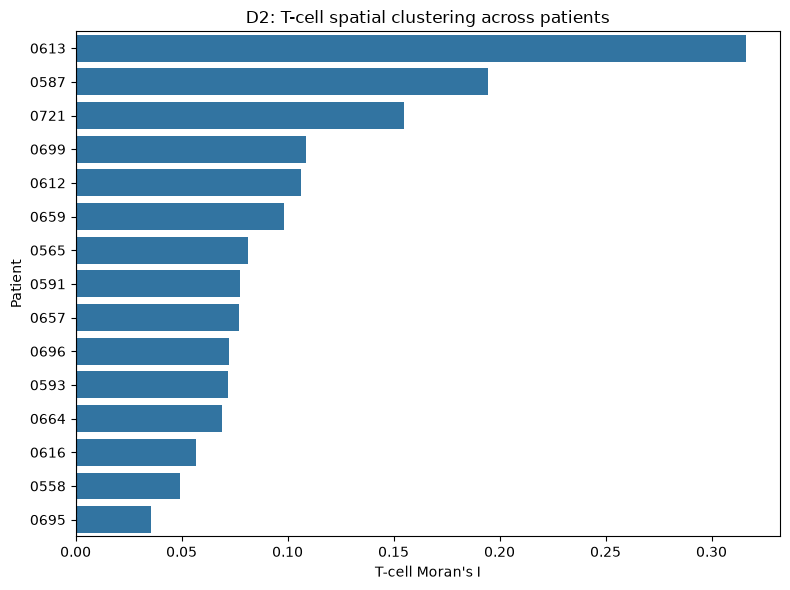

In [62]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=tcell_moran_df,
    x="tcell_moran_I",
    y="patient"
)

plt.axvline(0, color="black", linestyle="--")
plt.xlabel("T-cell Moran's I")
plt.ylabel("Patient")
plt.title("D2: T-cell spatial clustering across patients")
plt.tight_layout()
plt.show()

INTERPRETATION: T-cell Moran's I varied substantially across patients, ranging from approximately 0.04 to 0.32. Patient 0613 showed the strongest T-cell clustering, followed by patients 0587 and 0721. In contrast, patients 0695, 0558 and 0616 exhibited the weakest clustering. Overall, all Moran's I values were positive, indicating that T cells tend to form spatial clusters rather than being randomly distributed. However, the strength of clustering differed considerably between tumours, suggesting substantial variation in the spatial organisation of immune cells across patients.

#### Cross-patient interpretation

In [63]:
# Merge D1 infiltration score with D2 T-cell Moran's I.

d1_d2 = scores_df.merge(tcell_moran_df, on="patient", how="inner")

d1_d2

,patient,tcell_infiltration_score,n_tcells,pattern,tcell_moran_I,null_mean,null_low,null_high,p_value,n_tcells_subsample
0,0565,27.511816,21008,infiltrated,0.081354,-0.000100,-0.004484,0.003937,0.001996,5816
1,0591,27.089666,23156,infiltrated,0.077509,-0.000030,-0.003994,0.004045,0.001996,3718
2,0587,23.298712,57688,infiltrated,0.194519,-0.000004,-0.003956,0.004303,0.001996,9679
3,0612,22.370740,5363,infiltrated,0.106457,0.000226,-0.003850,0.004404,0.001996,1614
4,0616,20.618923,11477,infiltrated,0.056890,0.000060,-0.003978,0.004118,0.001996,3401
5,0721,20.188363,92884,mixed,0.155079,-0.000064,-0.003907,0.004120,0.001996,6592
6,0696,18.752333,28757,mixed,0.072451,-0.000140,-0.004054,0.004032,0.001996,6173
7,0664,17.740631,7706,mixed,0.068975,0.000017,-0.004102,0.003910,0.001996,4037
8,0695,17.548219,15124,mixed,0.035653,-0.000201,-0.004439,0.004178,0.001996,3166
9,0657,15.033629,8055,mixed,0.077025,-0.000023,-0.004087,0.004382,0.001996,4550


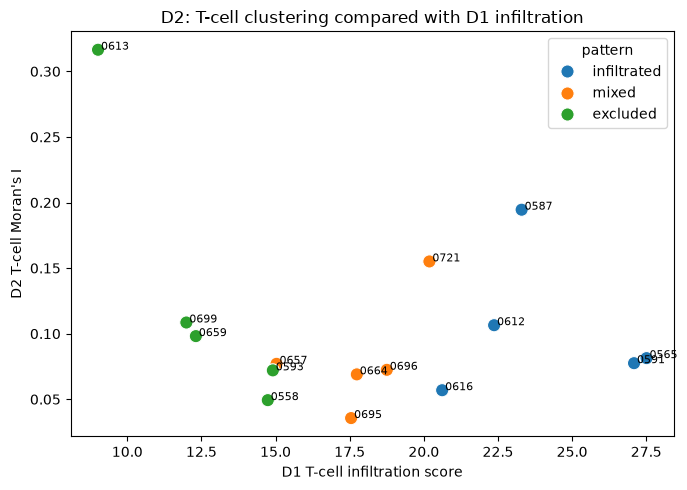

In [64]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=d1_d2,
    x="tcell_infiltration_score",
    y="tcell_moran_I",
    hue="pattern",
    s=90
)

for _, row in d1_d2.iterrows():
    plt.text(
        row["tcell_infiltration_score"] + 0.1,
        row["tcell_moran_I"],
        row["patient"],
        fontsize=8
    )

plt.xlabel("D1 T-cell infiltration score")
plt.ylabel("D2 T-cell Moran's I")
plt.title("D2: T-cell clustering compared with D1 infiltration")
plt.tight_layout()
plt.show()

INTERPRETATION: Comparison of D1 infiltration scores and D2 Moran's I values showed that T-cell infiltration and T-cell clustering describe different aspects of the tumour immune microenvironment. No strong linear relationship was observed between the two measures. For example, patient 0613 exhibited the strongest T-cell clustering (Moran's I ≈ 0.32) but the lowest infiltration score, indicating that T cells form dense local aggregates without penetrating deeply into tumour tissue. This pattern is consistent with an immune-excluded phenotype.

In contrast, patients 0565 and 0591 showed some of the highest infiltration scores while displaying only moderate Moran's I values. This suggests that T cells are distributed more broadly throughout the tumour rather than being concentrated in a few compact clusters. Patient 0587 combined both a high infiltration score and relatively high Moran's I, indicating the presence of clustered T-cell populations within deeper tumour regions.

Overall, the results suggest that D1 and D2 provide complementary information. D1 measures how deeply T cells penetrate into tumour tissue, whereas D2 quantifies how strongly T cells cluster spatially. Tumours with similar infiltration scores can therefore exhibit different spatial organisation patterns, and vice versa.

## D3: Patient Stratification from Spatial Features 

In [ ]:
# Spatial niches using neighbourhood composition.

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

K_NICHES = 6
K_NN_NICHE = 10
N_SUB_NICHE = 30000

CELL_TYPES_GLOBAL = [
    "CD15-Tumor", "CD15+Tumor", "Tcell", "Bcell",
    "BnTcell", "Macrophage", "DC", "Neutrophil", "other"
]

CT_INDEX = {ct: i for i, ct in enumerate(CELL_TYPES_GLOBAL)}

In [67]:
def compute_neighbourhood_composition(dataframe, k=10, n_sub=30000):
    """
    For a subsample of cells, compute local neighbourhood composition.

    For each sampled cell, we find k nearest neighbours and count what fraction
    of those neighbours belongs to each cell type.
    These vectors are later clustered into spatial niches.
    """

    df_work = dataframe.copy()
    n_sub_actual = min(n_sub, len(df_work))

    idx_sub = np.random.default_rng(42).choice(
        len(df_work),
        size=n_sub_actual,
        replace=False
    )

    coords = df_work[["nucleus.x", "nucleus.y"]].to_numpy()[idx_sub]
    types = df_work["cell.type"].to_numpy()[idx_sub]

    tree = cKDTree(coords)
    _, knn = tree.query(coords, k=k + 1)
    knn = knn[:, 1:]

    comp = np.zeros((n_sub_actual, len(CELL_TYPES_GLOBAL)))

    for i, neighbours in enumerate(knn):
        for nb in neighbours:
            ct = types[nb]
            if ct in CT_INDEX:
                comp[i, CT_INDEX[ct]] += 1

    comp = comp / k

    return comp, coords, df_work

In [ ]:
# Fit one global KMeans model across all patients.

all_compositions = []

for patient in sorted(df["patient"].unique()):
    patient_df = df[df["patient"] == patient].copy()
    comp, _, _ = compute_neighbourhood_composition(patient_df, k=K_NN_NICHE, n_sub=N_SUB_NICHE)
    all_compositions.append(comp)

all_compositions = np.vstack(all_compositions)

global_niche_model = KMeans(n_clusters=K_NICHES, random_state=42, n_init=10)

global_niche_model.fit(all_compositions)

print("Global niche model fitted.")
print("Training neighbourhood vectors:", all_compositions.shape)

Global niche model fitted.
Training neighbourhood vectors: (450000, 9)


In [70]:
def assign_niches_to_patient(dataframe, k=10, n_sub=30000):
    """
    Assign niches to all cells in one patient.

    We compute neighbourhood composition on a subsample, predict niche labels
    using the global model, then assign every full-resolution cell to the
    nearest sampled cell's niche.
    """

    comp, coords_sub, df_work = compute_neighbourhood_composition(
        dataframe,
        k=k,
        n_sub=n_sub
    )

    niche_sub = global_niche_model.predict(comp)

    coords_full = df_work[["nucleus.x", "nucleus.y"]].to_numpy()

    tree = cKDTree(coords_sub)
    _, nearest_sub = tree.query(coords_full, k=1)

    df_work["niche"] = niche_sub[nearest_sub]

    return df_work

In [71]:
def compute_niche_fractions(dataframe, n_niches=K_NICHES):
    """
    Fraction of all cells assigned to each niche.
    """

    counts = dataframe["niche"].value_counts()
    total = len(dataframe)

    return {
        f"NicheFrac_{i}": counts.get(i, 0) / total
        for i in range(n_niches)
    }


def compute_niche_self_adjacency(dataframe, n_niches=K_NICHES, k=10, n_sub=30000):
    """
    For each niche, compute how often cells of that niche have neighbours
    from the same niche.

    High self-adjacency means the niche forms spatially coherent regions.
    Low self-adjacency means the niche is more mixed with other niches.
    """

    n_sub_actual = min(n_sub, len(dataframe))

    idx = np.random.default_rng(42).choice(
        len(dataframe),
        size=n_sub_actual,
        replace=False
    )

    coords = dataframe[["nucleus.x", "nucleus.y"]].to_numpy()[idx]
    niches = dataframe["niche"].to_numpy()[idx]

    tree = cKDTree(coords)
    _, knn = tree.query(coords, k=k + 1)
    knn = knn[:, 1:]

    result = {}

    for niche_id in range(n_niches):
        mask = niches == niche_id

        if mask.sum() == 0:
            result[f"NicheSelfAdj_{niche_id}"] = 0.0
        else:
            neighbour_niches = niches[knn[mask]]
            result[f"NicheSelfAdj_{niche_id}"] = (neighbour_niches == niche_id).mean()

    return result

In [ ]:
# Prepare D1 and D2 values for merging

d1_for_d3 = scores_df[["patient", "tcell_infiltration_score"]].copy()
d1_for_d3 = d1_for_d3.rename(columns={
    "tcell_infiltration_score": "T_Infil_Score"
})

d2_for_d3 = tcell_moran_df[["patient", "tcell_moran_I"]].copy()
d2_for_d3 = d2_for_d3.rename(columns={
    "tcell_moran_I": "T_Moran_I"
})

In [ ]:
# Build one row per patient:
# niche fractions + niche self-adjacency value + T-cell infiltration score, + T-cell Moran's I.

records = []

for patient in sorted(df["patient"].unique()):
    print("Processing patient:", patient)

    patient_df = df[df["patient"] == patient].copy()

    patient_with_niches = assign_niches_to_patient(
        patient_df,
        k=K_NN_NICHE,
        n_sub=N_SUB_NICHE
    )

    frac_features = compute_niche_fractions(patient_with_niches)
    adj_features = compute_niche_self_adjacency(
        patient_with_niches,
        k=K_NN_NICHE,
        n_sub=N_SUB_NICHE
    )

    row = {"patient": patient}
    row.update(frac_features)
    row.update(adj_features)

    records.append(row)

niche_features = pd.DataFrame(records)

feature_matrix = (
    niche_features
    .merge(d1_for_d3, on="patient", how="left")
    .merge(d2_for_d3, on="patient", how="left")
)

feature_matrix

Processing patient: 0558
Processing patient: 0565
Processing patient: 0587
Processing patient: 0591
Processing patient: 0593
Processing patient: 0612
Processing patient: 0613
Processing patient: 0616
Processing patient: 0657
Processing patient: 0659
Processing patient: 0664
Processing patient: 0695
Processing patient: 0696
Processing patient: 0699
Processing patient: 0721


,patient,NicheFrac_0,NicheFrac_1,NicheFrac_2,NicheFrac_3,NicheFrac_4,NicheFrac_5,NicheSelfAdj_0,NicheSelfAdj_1,NicheSelfAdj_2,NicheSelfAdj_3,NicheSelfAdj_4,NicheSelfAdj_5,T_Infil_Score,T_Moran_I
0,0558,0.308182,0.095853,0.094697,0.484125,0.004609,0.012533,0.646713,0.365485,0.457671,0.724607,0.268794,0.460000,14.738385,0.049322
1,0565,0.122836,0.188214,0.209264,0.241112,0.234329,0.004245,0.627300,0.490057,0.482569,0.738206,0.711708,0.410791,27.511816,0.081354
2,0587,0.269077,0.170422,0.140611,0.309479,0.104873,0.005537,0.739315,0.493833,0.486344,0.746985,0.638822,0.802825,23.298712,0.194519
3,0591,0.125562,0.164923,0.333494,0.125983,0.173642,0.076396,0.704002,0.465383,0.577285,0.598449,0.569184,0.613945,27.089666,0.077509
4,0593,0.257886,0.364058,0.131260,0.168703,0.067995,0.010100,0.647874,0.595549,0.426768,0.628803,0.443854,0.415488,14.908387,0.072029
5,0612,0.061481,0.148659,0.102073,0.040428,0.646751,0.000608,0.632116,0.497524,0.454581,0.591002,0.902407,0.563636,22.370740,0.106457
6,0613,0.201233,0.128488,0.035263,0.332553,0.296049,0.006414,0.732911,0.497971,0.298307,0.877490,0.860972,0.554450,9.013878,0.316482
7,0616,0.115666,0.280189,0.262346,0.105147,0.223199,0.013452,0.592355,0.534875,0.534945,0.626679,0.621361,0.511348,20.618923,0.056890
8,0657,0.247446,0.370803,0.097791,0.138736,0.145108,0.000115,0.653010,0.599745,0.393095,0.688438,0.665488,0.050000,15.033629,0.077025
9,0659,0.101599,0.249666,0.279355,0.191298,0.162832,0.015251,0.550913,0.515456,0.542491,0.659472,0.572131,0.465487,12.313001,0.098143


In [74]:
print("Feature matrix shape:", feature_matrix.shape)
print("Missing values:")
print(feature_matrix.isna().sum())

feature_matrix.to_csv("d3_feature_matrix.csv", index=False)

Feature matrix shape: (15, 15)
Missing values:
patient           0
NicheFrac_0       0
NicheFrac_1       0
NicheFrac_2       0
NicheFrac_3       0
NicheFrac_4       0
NicheFrac_5       0
NicheSelfAdj_0    0
NicheSelfAdj_1    0
NicheSelfAdj_2    0
NicheSelfAdj_3    0
NicheSelfAdj_4    0
NicheSelfAdj_5    0
T_Infil_Score     0
T_Moran_I         0
dtype: int64


#### Niche interpretation

In [88]:
# Visualise niche centroids.
# Each centroid represents the average neighbourhood composition
# of cells assigned to a given niche.

centroids = pd.DataFrame(global_niche_model.cluster_centers_, columns=CELL_TYPES_GLOBAL)

centroids.index = [
    f"Niche {i}"
    for i in range(K_NICHES)
]

centroids

,CD15-Tumor,CD15+Tumor,Tcell,Bcell,BnTcell,Macrophage,DC,Neutrophil,other
Niche 0,0.104036,0.010862,0.112600,0.013905,0.006843,0.083134,0.002066,0.020237,0.646317
Niche 1,0.431495,0.015751,0.075669,0.006367,0.003093,0.061854,0.002026,0.017738,0.386008
Niche 2,0.483332,0.034631,0.151943,0.015993,0.009552,0.138462,0.003145,0.029843,0.133100
Niche 3,0.110295,0.012080,0.364425,0.073298,0.058239,0.117467,0.002890,0.019054,0.242252
Niche 4,0.796829,0.013201,0.034265,0.003128,0.000973,0.029330,0.000767,0.007849,0.113657
Niche 5,0.148758,0.333380,0.043956,0.008862,0.002890,0.038086,0.000988,0.283927,0.139154


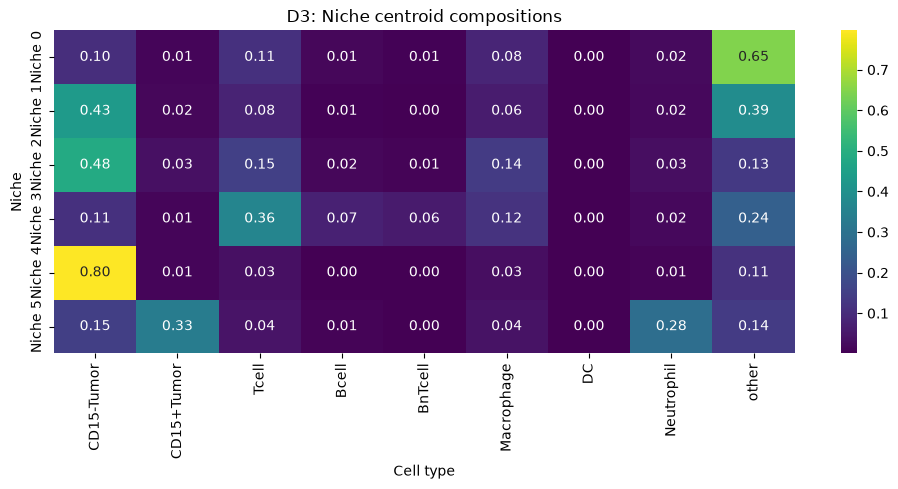

In [89]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    centroids,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

plt.title("D3: Niche centroid compositions")
plt.xlabel("Cell type")
plt.ylabel("Niche")

plt.tight_layout()
plt.show()

In [90]:
for niche_id in range(K_NICHES):

    print(f"\nNiche {niche_id}")

    print(
        centroids.loc[f"Niche {niche_id}"]
        .sort_values(ascending=False)
        .head(5)
    )


Niche 0
other         0.646317
Tcell         0.112600
CD15-Tumor    0.104036
Macrophage    0.083134
Neutrophil    0.020237
Name: Niche 0, dtype: float64

Niche 1
CD15-Tumor    0.431495
other         0.386008
Tcell         0.075669
Macrophage    0.061854
Neutrophil    0.017738
Name: Niche 1, dtype: float64

Niche 2
CD15-Tumor    0.483332
Tcell         0.151943
Macrophage    0.138462
other         0.133100
CD15+Tumor    0.034631
Name: Niche 2, dtype: float64

Niche 3
Tcell         0.364425
other         0.242252
Macrophage    0.117467
CD15-Tumor    0.110295
Bcell         0.073298
Name: Niche 3, dtype: float64

Niche 4
CD15-Tumor    0.796829
other         0.113657
Tcell         0.034265
Macrophage    0.029330
CD15+Tumor    0.013201
Name: Niche 4, dtype: float64

Niche 5
CD15+Tumor    0.333380
Neutrophil    0.283927
CD15-Tumor    0.148758
other         0.139154
Tcell         0.043956
Name: Niche 5, dtype: float64


INTERPRETATION: Six spatial niches were identified based on local neighbourhood composition. Niche 4 was strongly dominated by CD15-Tumor cells and was therefore interpreted as a core tumour niche. Niche 1 was also tumour-rich, although less extreme, containing approximately 43% CD15-Tumor cells together with a large proportion of cells classified as "other", and was interpreted as a tumour-rich niche. Niche 2 contained high proportions of CD15-Tumor cells together with elevated fractions of T cells and macrophages, suggesting an immune-infiltrated tumour niche. Niche 3 showed the highest abundance of lymphocytes, including T cells, B cells and BnT cells, and was interpreted as a lymphocyte-rich niche. Niche 5 was characterised by elevated fractions of CD15+Tumor cells and neutrophils and was therefore interpreted as a neutrophil-associated tumour niche. Finally, Niche 0 contained a heterogeneous mixture of cell types with a large proportion of "other" cells and was interpreted as a mixed stromal niche.

#### Standardisation

In [75]:
# Remove patient column.
X = feature_matrix.drop(columns=["patient"])

# Z-score standardisation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "patient": feature_matrix["patient"],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})

pca_df.head()

,patient,PC1,PC2
0,0558,-3.096177,-1.066091
1,0565,-0.229426,0.791752
2,0587,-2.458764,-0.857267
3,0591,-1.024143,2.948716
4,0593,0.928357,-0.945445


#### Explained variance

In [78]:
explained = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained[0]:.3f}")
print(f"PC2 explained variance: {explained[1]:.3f}")
print(f"Total: {(explained[0] + explained[1]):.3f}")

PC1 explained variance: 0.338
PC2 explained variance: 0.265
Total: 0.603


#### PCA plot

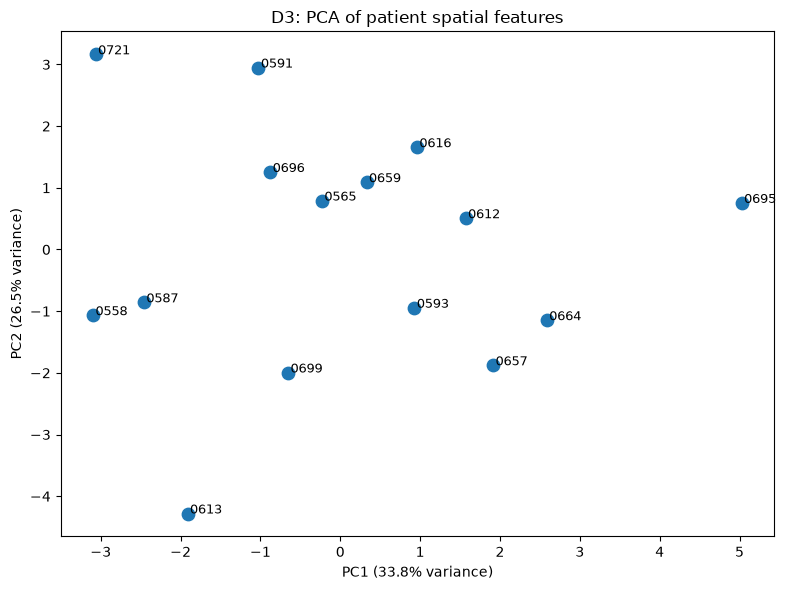

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=80
)

for _, row in pca_df.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"],
        row["patient"],
        fontsize=9
    )

plt.xlabel(
    f"PC1 ({explained[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({explained[1]*100:.1f}% variance)"
)

plt.title("D3: PCA of patient spatial features")

plt.tight_layout()
plt.show()

INTERPRETATION: The first two principal components explained approximately 60% of the total variance (PC1: 33.8%, PC2: 26.5%). PC1 was driven mainly by differences in niche composition, particularly the relative abundance of the tumour-rich niche (Niche 1), the core tumour niche (Niche 4) and the lymphocyte-rich niche (Niche 3), as well as their self-adjacency values. PC2 was influenced primarily by the immune-infiltrated tumour niche (Niche 2), its self-adjacency, and the T-cell infiltration score from D1. These results indicate that patient differences are determined both by local niche organisation and by the extent of immune-cell infiltration into tumour tissue.

#### Clustering patients

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)

pca_df["cluster"] = kmeans.fit_predict(pca_df[["PC1", "PC2"]])

Clustering was performed using k=3 clusters, which provided a biologically interpretable separation of infiltrated, mixed and immune-excluded patients.

#### PCA coloured by cluster

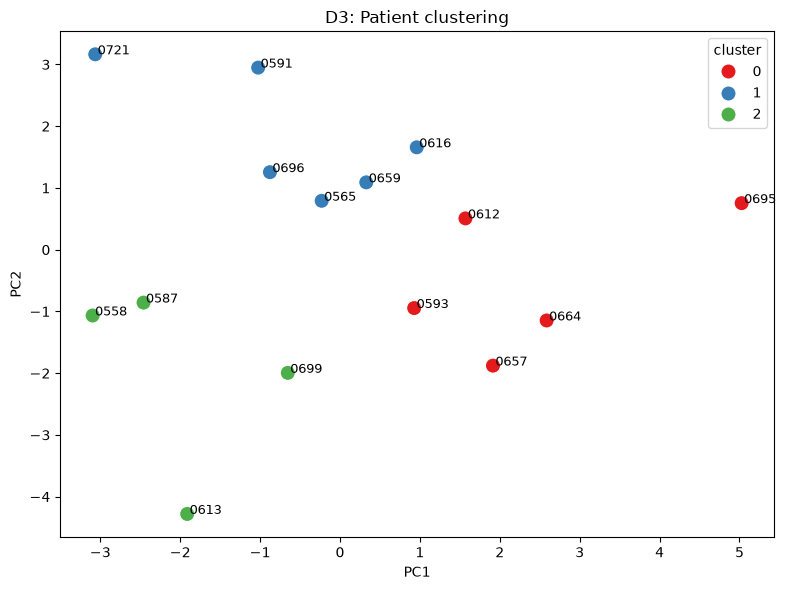

In [82]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    s=120
)

for _, row in pca_df.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"],
        row["patient"],
        fontsize=9
    )

plt.title("D3: Patient clustering")
plt.tight_layout()
plt.show()

In [83]:
cluster_summary = (
    feature_matrix
    .merge(
        pca_df[["patient", "cluster"]],
        on="patient"
    )
    .groupby("cluster")
    .mean(numeric_only=True)
)

cluster_summary.round(3)

,NicheFrac_0,NicheFrac_1,NicheFrac_2,NicheFrac_3,NicheFrac_4,NicheFrac_5,NicheSelfAdj_0,NicheSelfAdj_1,NicheSelfAdj_2,NicheSelfAdj_3,NicheSelfAdj_4,NicheSelfAdj_5,T_Infil_Score,T_Moran_I
cluster,,,,,,,,,,,,,,
0,0.161,0.337,0.115,0.086,0.298,0.002,0.609,0.579,0.404,0.584,0.660,0.256,17.520,0.072
1,0.118,0.202,0.259,0.171,0.160,0.089,0.634,0.493,0.539,0.649,0.573,0.602,21.079,0.090
2,0.285,0.159,0.090,0.322,0.126,0.018,0.711,0.470,0.405,0.746,0.591,0.608,14.761,0.167


#### Feature importance

In [85]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])

loadings

,PC1,PC2
NicheFrac_0,-0.164345,-0.347699
NicheFrac_1,0.385382,-0.069636
NicheFrac_2,-0.062831,0.461717
NicheFrac_3,-0.353133,-0.192985
NicheFrac_4,0.252085,0.006979
NicheFrac_5,-0.214169,0.286879
NicheSelfAdj_0,-0.318372,-0.168597
NicheSelfAdj_1,0.362968,-0.116489
NicheSelfAdj_2,-0.167977,0.460370
NicheSelfAdj_3,-0.323316,-0.261559


In [86]:
loadings["abs_PC1"] = np.abs(loadings["PC1"])

loadings.sort_values("abs_PC1", ascending=False).head(10)

,PC1,PC2,abs_PC1
NicheFrac_1,0.385382,-0.069636,0.385382
NicheSelfAdj_5,-0.372114,0.150220,0.372114
NicheSelfAdj_1,0.362968,-0.116489,0.362968
NicheFrac_3,-0.353133,-0.192985,0.353133
NicheSelfAdj_3,-0.323316,-0.261559,0.323316
NicheSelfAdj_0,-0.318372,-0.168597,0.318372
NicheFrac_4,0.252085,0.006979,0.252085
T_Moran_I,-0.228891,-0.241926,0.228891
NicheFrac_5,-0.214169,0.286879,0.214169
NicheSelfAdj_4,0.171849,-0.136950,0.171849


In [87]:
loadings["abs_PC2"] = np.abs(loadings["PC2"])

loadings.sort_values( "abs_PC2", ascending=False).head(10)

,PC1,PC2,abs_PC1,abs_PC2
NicheFrac_2,-0.062831,0.461717,0.062831,0.461717
NicheSelfAdj_2,-0.167977,0.460370,0.167977,0.460370
NicheFrac_0,-0.164345,-0.347699,0.164345,0.347699
T_Infil_Score,-0.012549,0.345376,0.012549,0.345376
NicheFrac_5,-0.214169,0.286879,0.214169,0.286879
NicheSelfAdj_3,-0.323316,-0.261559,0.323316,0.261559
T_Moran_I,-0.228891,-0.241926,0.228891,0.241926
NicheFrac_3,-0.353133,-0.192985,0.353133,0.192985
NicheSelfAdj_0,-0.318372,-0.168597,0.318372,0.168597
NicheSelfAdj_5,-0.372114,0.150220,0.372114,0.150220


#### Biologigal interpretation

Clustering of patients in PCA space identified three groups with distinct spatial characteristics. Patients in Cluster 1 showed the highest T-cell infiltration scores and larger fractions of the immune-infiltrated tumour niche, indicating an inflamed/infiltrated phenotype with effective immune-cell penetration into tumour tissue. Patients in Cluster 2 exhibited the lowest infiltration scores together with the highest T-cell Moran's I values, suggesting an immune-excluded phenotype in which T cells form local aggregates but remain restricted to tumour borders or specific regions. Cluster 0 displayed intermediate values for both infiltration and clustering and contained a mixture of tumour-rich and immune-containing niches, representing a mixed phenotype. Overall, the main drivers of patient differences were the balance between tumour-dominated niches, lymphocyte-rich niches and immune-infiltrated tumour niches, together with variation in T-cell infiltration and spatial clustering. These findings demonstrate substantial heterogeneity in the spatial organisation of the lung tumour microenvironment across patients.